In [2]:
# load config and QC-filtered data

import os 
os.chdir("C:/Users/ASRENOVIN/Desktop/spatial-foundation-graph-transformer")

import yaml
import scanpy as sc
import anndata as ad

with open("configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

adata = ad.read_h5ad("data/processed/adata_qc.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 3661 × 20955
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'


In [3]:
# normalize library size and log1p transform

sc.pp.normalize_total(adata, target_sum=cfg["preprocessing"]["normalize_total"])
sc.pp.log1p(adata)

print("Normalization complete.")
print("X min:", adata.X.min().round(4))
print("X max:", adata.X.max().round(4))

Normalization complete.
X min: 0.0
X max: 7.5746


In [4]:
# select_hvgs (identify the most informative genes for downstream analysis)
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=cfg["preprocessing"]["n_hvgs"],
    flavor="seurat_v3",
    layer=None,
)

print("Highly variable genes:", adata.var["highly_variable"].sum())
print("Total genes          :", adata.n_vars)

C:\ProgramData\miniconda3\envs\sfgt\lib\site-packages\legacy_api_wrap\__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


Highly variable genes: 3000
Total genes          : 20955


In [5]:
# run_pca (reduce HVG expression matrix to 50 principal components)
sc.pp.pca(
    adata,
    n_comps=cfg["preprocessing"]["n_pca_components"],
    mask_var="highly_variable",
)

print("PCA complete.")
print("Shape of PCA embedding:", adata.obsm["X_pca"].shape)

PCA complete.
Shape of PCA embedding: (3661, 50)


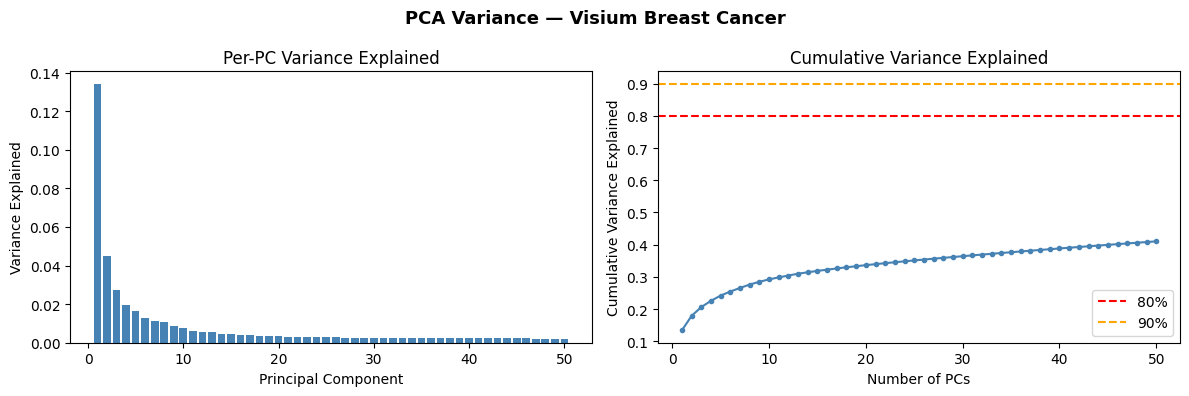

Saved: figures/evaluation/pca_variance.png


In [9]:
# plot_pca_variance: check how much variance the top 50 PCs capture
import matplotlib.pyplot as plt
import numpy as np

variance_ratio = adata.uns["pca"]["variance_ratio"]
cumulative = np.cumsum(variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 51), variance_ratio, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained")
axes[0].set_title("Per-PC Variance Explained")

axes[1].plot(range(1, 51), cumulative, color="steelblue", marker="o", markersize=3)
axes[1].axhline(0.8, color="red", linestyle="--", label="80%")
axes[1].axhline(0.9, color="orange", linestyle="--", label="90%")
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative Variance Explained")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()

plt.suptitle("PCA Variance — Visium Breast Cancer", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/evaluation/pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/evaluation/pca_variance.png")

In [6]:
# save_normalized adata
adata.write_h5ad("data/processed/adata_normalized.h5ad")

print("Saved: data/processed/adata_normalized.h5ad")
print("Spots:", adata.n_obs)
print("Genes:", adata.n_vars)
print("HVGs :", adata.var["highly_variable"].sum())
print("PCA  :", adata.obsm["X_pca"].shape)

Saved: data/processed/adata_normalized.h5ad
Spots: 3661
Genes: 20955
HVGs : 3000
PCA  : (3661, 50)


In [7]:
# write_normalization_module: package normalization steps as a reusable src module
norm_code = '''from __future__ import annotations
from typing import Any
import scanpy as sc
import anndata as ad


def normalize(adata: ad.AnnData, cfg: dict[str, Any]) -> ad.AnnData:
    """
    Normalize counts, log1p transform, select HVGs, and run PCA.

    Parameters
    ----------
    adata : AnnData  QC-filtered count matrix.
    cfg   : dict     Master config (uses cfg["preprocessing"]).

    Returns
    -------
    AnnData  Normalized object with HVGs flagged and X_pca in obsm.
    """
    pp = cfg["preprocessing"]

    sc.pp.normalize_total(adata, target_sum=pp["normalize_total"])
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=pp["n_hvgs"],
        flavor="seurat_v3",
    )
    sc.pp.pca(adata, n_comps=pp["n_pca_components"], use_highly_variable=True)

    return adata
'''

with open("src/preprocessing/normalization.py", "w") as f:
    f.write(norm_code)

print("Created: src/preprocessing/normalization.py")

Created: src/preprocessing/normalization.py
